#### Importar librerias

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
import matplotlib.dates as mdatesx
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from scipy.interpolate import make_interp_spline
from matplotlib.ticker import FuncFormatter
import calendar

#### Seleccionar Fecha

In [ ]:
ANIO = 2026
MES = 3

df = pd.DataFrame()
df["anio"] = ANIO
df["mes"] = MES

fecha_corte = pd.Timestamp(year=ANIO, month=MES, day=1) + pd.offsets.MonthEnd(0)

#### Drive - Colab

In [ ]:
######### Para usar con colab ###########
### Comentar si se usa fuera de colab ###
"""
import os
from google.colab import drive

drive.mount('/content/drive')
ruta_drive = r"/content/drive/MyDrive/_DPAEE/Automatización de Informes"
os.listdir(ruta_drive)

carpeta = f"{ANIO}-{MES}"
ruta_completa = os.path.join(ruta_drive, carpeta)

# Crear carpeta (no tira error si ya existe)
os.makedirs(ruta_completa, exist_ok=True)

#### Entorno local

In [ ]:
                                                                                                                                                                                                    ############## Para usar en entorno local #################
###### Comentar si se usa fuera de un entorno local #######

ruta_carpeta = r"C:\Users\janis\Desktop\DPAEE\Automatización de Informes\Fiscal"
ruta = r"C:\Users\janis\Desktop\DPAEE\Automatización de Informes\Fiscal\Gráficos Fiscal\Municipios"

carpeta = f"{ANIO}-{MES}"

ruta_completa = os.path.join(ruta, carpeta)

print("Ruta final:")
print(ruta_completa)

print("Existe ruta padre:", os.path.exists(ruta))

# Crear carpeta
os.makedirs(ruta_completa, exist_ok=True)

print("Carpeta creada correctamente")

Ruta final:
C:\Users\janis\Desktop\DPAEE\Automatización de Informes\Fiscal\Gráficos Fiscal\Municipios\2026-3
Existe ruta padre: True
Carpeta creada correctamente


#### BBDD - Todas

In [ ]:
fiscal_rcp = pd.read_excel(f'{ruta_carpeta}/Fiscal_BBDD.xlsx', sheet_name='RCP')
fiscal_tyd = pd.read_excel(f'{ruta_carpeta}/Fiscal_BBDD.xlsx', sheet_name='TYD')
fiscal_municipios = pd.read_excel(f"{ruta_carpeta}/Fiscal_BBDD.xlsx", sheet_name='Transferencias_municipios')
fiscal_fondos = pd.read_excel(f"{ruta_carpeta}/Fiscal_BBDD.xlsx", sheet_name='Transferencias_fondos')
fiscal_municipios.columns = fiscal_municipios.columns.str.strip()
pd.set_option('display.float_format', '{:.2f}'.format)

fiscal_otros = fiscal_rcp.copy()

# Identificar columnas numéricas
cols_numericas = fiscal_rcp.select_dtypes(include='number').columns[1:]

# Restar
fiscal_otros[cols_numericas] = (
    fiscal_rcp[cols_numericas] - fiscal_tyd[cols_numericas])


fiscal_rcp = fiscal_rcp.set_index('fecha')
fiscal_tyd = fiscal_tyd.set_index('fecha')
fiscal_otros = fiscal_otros.set_index('fecha')
fiscal_municipios = fiscal_municipios.set_index('fecha')
fiscal_fondos = fiscal_fondos.set_index('fecha')

pd.to_datetime(fiscal_rcp.index)
pd.to_datetime(fiscal_tyd.index)
pd.to_datetime(fiscal_otros.index)
pd.to_datetime(fiscal_municipios.index)
pd.to_datetime(fiscal_fondos.index)

# Organiza mejor los cálculos posteriores
columnas_municipios = (fiscal_rcp.columns.drop('IPC Dic16=100'))

# Serie dummy para identificar que valores son nulos
dummy_municipios = (
    fiscal_rcp[fiscal_rcp.index.to_period('M') == fecha_corte.to_period('M')]
    .iloc[:, 1:]
    .gt(0)
    .astype(int)
    .iloc[0]
)


municipios_disponibles = dummy_municipios[dummy_municipios == 1].index
municipios_disponibles


Index(['adolfo_alsina', 'adolfo_gonzales_chaves', 'alberti', 'almirante_brown',
       'arrecifes', 'avellaneda', 'ayacucho', 'azul', 'bahia_blanca',
       'balcarce',
       ...
       'tigre', 'tordillo', 'tornquist', 'trenque_lauquen', 'tres_arroyos',
       'tres_de_febrero', 'tres_lomas', '25_de_mayo', 'vicente_lopez',
       'villarino'],
      dtype='str', length=125)

In [ ]:
# Crear Deflactor sobre el último dato de IPC

ipc_base = fiscal_municipios.loc[:fecha_corte, 'IPC Dic16=100'].iloc[-1]
ipc_base_fondos = fiscal_fondos.loc[:fecha_corte, 'IPC Dic16=100'].iloc[-1]
ipc_base_rcp = fiscal_rcp.loc[:fecha_corte, 'IPC Dic16=100'].iloc[-1]
ipc_base_tyd = fiscal_tyd.loc[:fecha_corte, 'IPC Dic16=100'].iloc[-1]
ipc_base_otros= fiscal_otros.loc[:fecha_corte, 'IPC Dic16=100'].iloc[-1]

In [ ]:
fiscal_fondos['resto_transferencias'] = fiscal_fondos['total'] - fiscal_fondos['coparticipacion_bruta']

cols = fiscal_fondos.select_dtypes(include='number').columns

for col in cols:
    fiscal_fondos[f'{col}_defl'] = fiscal_fondos[col] * ipc_base_fondos / fiscal_fondos['IPC Dic16=100']


In [ ]:
# seleccionar columnas que terminan en _defl
cols = fiscal_fondos.filter(like='_defl').columns

# calcular acumulado anual
acum = (
    fiscal_fondos[cols]
    .groupby(fiscal_fondos.index.year)
    .cumsum()
)

# renombrar columnas
acum.columns = [col + '_acum' for col in acum.columns]

# unir al dataframe original
fiscal_fondos = pd.concat([fiscal_fondos, acum], axis=1)

df_filtrado_fondos = fiscal_fondos.loc[:fecha_corte].copy()

## Recursos Propios + Tasas y Derechos

In [ ]:
# Cálculo del total corriente - 135 municipios

fiscal_rcp['Total_rcp'] = fiscal_rcp[columnas_municipios].sum(axis=1)
fiscal_tyd['Total_tyd'] = fiscal_tyd[columnas_municipios].sum(axis=1)
fiscal_otros['Total_otros']= fiscal_otros[columnas_municipios].sum(axis=1)


# Calculo del total deflactado - 135 municipios
fiscal_rcp['Total_rcp_defl'] = (
    fiscal_rcp['Total_rcp'] * ipc_base_rcp / fiscal_rcp['IPC Dic16=100'])

fiscal_tyd['Total_tyd_defl'] = (
    fiscal_tyd['Total_tyd'] * ipc_base_rcp / fiscal_tyd['IPC Dic16=100'])

fiscal_otros['Total_otros_defl'] = (
    fiscal_otros['Total_otros'] * ipc_base_rcp / fiscal_otros['IPC Dic16=100'])



# Cálculo del total corriente - Municipios Disponibles en el último mes

fiscal_rcp['Total_rcp_mun_disp'] = (fiscal_rcp[municipios_disponibles].sum(axis=1))
fiscal_tyd['Total_tyd_mun_disp'] = (fiscal_tyd[municipios_disponibles].sum(axis=1))
fiscal_otros['Total_otros_mun_disp'] = (fiscal_otros[municipios_disponibles].sum(axis=1))


# Calculo del total deflactado - Municipios Disponibles en el último mes
fiscal_rcp['Total_rcp_mun_disp_defl'] = (
    fiscal_rcp['Total_rcp_mun_disp'] * ipc_base_rcp / fiscal_rcp['IPC Dic16=100'])

fiscal_tyd['Total_tyd_mun_disp_defl'] = (
    fiscal_tyd['Total_tyd_mun_disp'] * ipc_base_rcp / fiscal_tyd['IPC Dic16=100'])

fiscal_otros['Total_otros_mun_disp_defl'] = (
    fiscal_otros['Total_otros_mun_disp'] * ipc_base_rcp / fiscal_otros['IPC Dic16=100'])

fiscal_rcp['rcp_restante_defl'] = fiscal_rcp['Total_rcp_defl'] - fiscal_rcp['Total_rcp_mun_disp_defl']



df_filtrado_rcp = fiscal_rcp.loc[:fecha_corte].copy()
df_filtrado_tyd = fiscal_tyd.loc[:fecha_corte].copy()
df_filtrado_otros = fiscal_otros.loc[:fecha_corte].copy()


C:\Users\janis\AppData\Local\Temp\ipykernel_24564\233085024.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fiscal_rcp['Total_rcp'] = fiscal_rcp[columnas_municipios].sum(axis=1)
C:\Users\janis\AppData\Local\Temp\ipykernel_24564\233085024.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fiscal_tyd['Total_tyd'] = fiscal_tyd[columnas_municipios].sum(axis=1)
C:\Users\janis\AppData\Local\Temp\ipykernel_24564\233085024.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

#### Gráfico de barras apiladas de los últimos 13 meses
* Recursos Propios
* Tasa y Derechos
* Otros

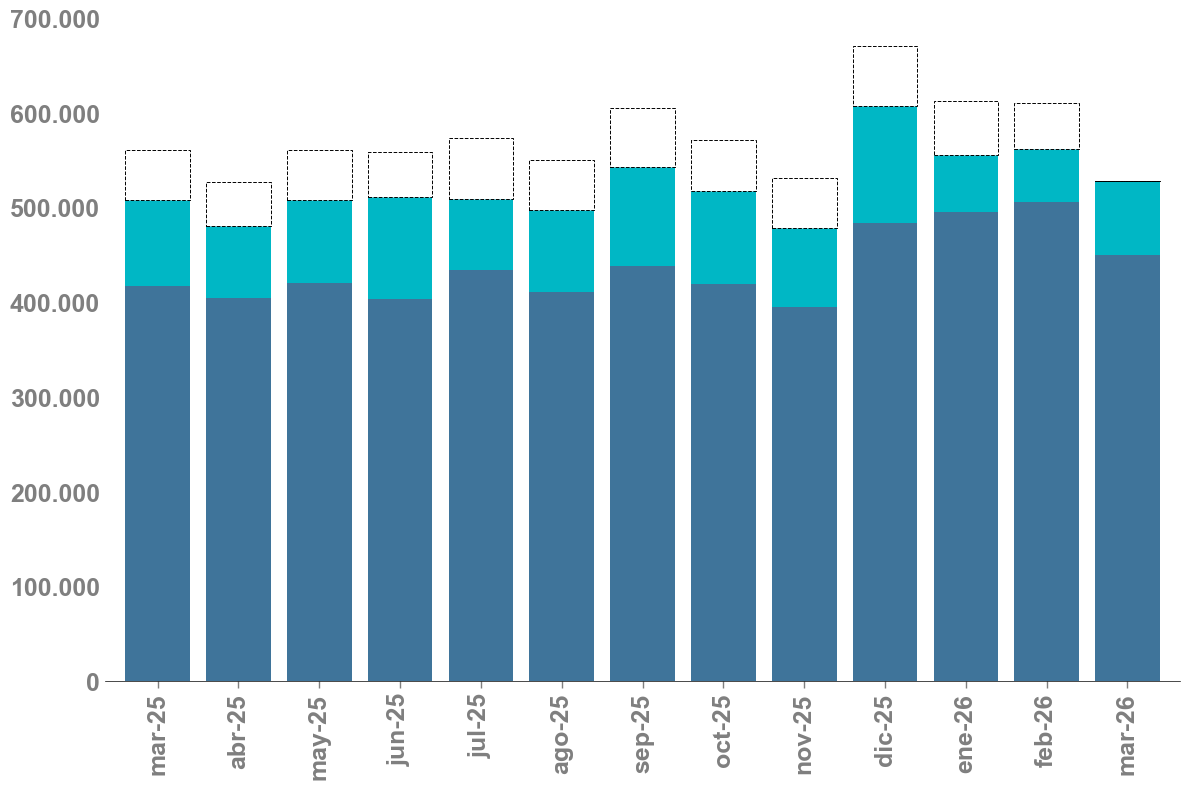

In [ ]:
# -------------------------------
# PREPARACIÓN DE DATOS
# -------------------------------

serie_rcp = df_filtrado_tyd['Total_tyd_mun_disp_defl'].tail(13)
serie_tyd = df_filtrado_otros['Total_otros_mun_disp_defl'].tail(13)
serie_otros = df_filtrado_rcp['rcp_restante_defl'].tail(13)

df_graf_1 = pd.concat(
    [serie_rcp, serie_tyd, serie_otros],
    axis=1
)

df_graf_1.columns = ['RCP', 'TyD', 'Otros']

# -------------------------------
# GENERAR ETIQUETAS DE FECHA
# -------------------------------

fechas_datetime = pd.to_datetime(df_graf_1.index)

meses_esp = [
    'ene', 'feb', 'mar', 'abr', 'may', 'jun',
    'jul', 'ago', 'sep', 'oct', 'nov', 'dic'
]

fechas_esp = [
    f"{meses_esp[d.month - 1]}-{str(d.year)[-2:]}"
    for d in fechas_datetime
]

# IMPORTANTE:
# convertir índice a string para evitar bug de pandas
df_graf_1.index = fechas_esp

# -------------------------------
# CREAR FIGURA
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

df_graf_1.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#3F749A', '#00B7C5', '#FFFFFF'],
    width=0.8,
    legend=False
)

# Agregar borde negro a las barras 'Otros'
bars = ax.containers[2]
for bar in bars:
    bar.set_edgecolor('black')
    bar.set_linewidth(0.7)
    bar.set_linestyle('dashed')
# -------------------------------
# EJE X
# -------------------------------

ax.set_xlabel('')

# -------------------------------
# EJE Y
# -------------------------------

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f'{int(x / 1e6):,}'.replace(',', '.')
    )
)

# -------------------------------
# ESTÉTICA
# -------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.spines['bottom'].set_linewidth(0.5)

ax.tick_params(
    axis='x',
    which='major',
    length=5,
    width=1,
    color='#7F7F7F',
    rotation = 90
)

ax.tick_params(
    axis='y',
    length=0
)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(18)
    label.set_color('#7F7F7F')

#ax.set_ylabel(
#    'Millones de $',
#    fontname='Arial',
#    fontweight='bold',
#    fontsize=18,
#    color='#7F7F7F'
#)

# -------------------------------
# LEYENDA
# -------------------------------

#legend = ax.legend(
#    loc='upper center',
#    bbox_to_anchor=(0.5, -0.12),
#    ncol=3,
#    frameon=False,
#    fontsize=16
#)

#for text in legend.get_texts():
#    text.set_fontname('Arial')
#    text.set_fontweight('bold')
#    text.set_color('#7F7F7F')

# -------------------------------
# FINAL
# -------------------------------

plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '1. Barras apiladas de los últimos 13 meses.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de líneas YoY + Barras
* Tasas y derechos
* RCP
* Otros

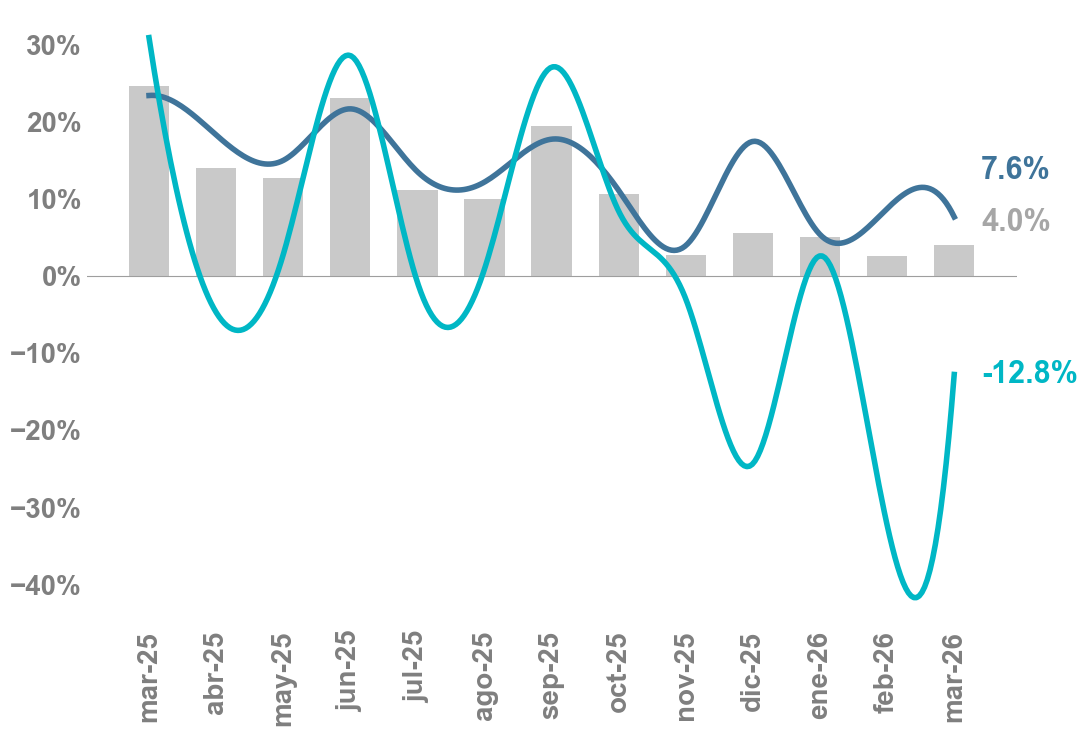

In [ ]:
# -------------------------------
# DATOS
# -------------------------------

df_vi = pd.DataFrame({
    'tyd_defl': df_filtrado_tyd['Total_tyd_mun_disp_defl'],
    'rcp_defl': df_filtrado_rcp['Total_rcp_mun_disp_defl'],
    'otros_defl': df_filtrado_otros['Total_otros_mun_disp_defl']
})

# Variación interanual
df_vi = df_vi.pct_change(12) * 100

# Últimos 13 meses
df_vi = df_vi.dropna().tail(13)

x = np.arange(len(df_vi))

# -------------------------------
# COLORES
# -------------------------------

colors = {
    'tyd_defl': '#3F749A',
    'rcp_defl': '#A6A6A6',
    'otros_defl': '#00B7C5'
}

# -------------------------------
# FIGURA
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

# -------------------------------
# RANKING PARA ETIQUETAS
# -------------------------------

last_vals = [
    (col, df_vi[col].iloc[-1])
    for col in df_vi.columns
]

last_vals_sorted = sorted(last_vals, key=lambda x: x[1])

rank_dict = {
    col: rank
    for rank, (col, _) in enumerate(last_vals_sorted)
}

# -------------------------------
# PLOTEO
# -------------------------------

for col in df_vi.columns:

    y = df_vi[col].values

    # -------------------------------
    # BARRAS GRISES
    # -------------------------------

    if col == 'rcp_defl':

        ax.bar(
            x,
            y,
            color=colors[col],
            width=0.6,
            alpha=0.6,
            zorder=1,
            label='Recursos Propios Corrientes'
        )

    # -------------------------------
    # LÍNEAS
    # -------------------------------

    else:

        x_new = np.linspace(x.min(), x.max(), 300)

        spline = make_interp_spline(x, y, k=3)

        y_smooth = spline(x_new)

        label_name = (
            'Tasas y Derechos'
            if col == 'tyd_defl'
            else 'Otros ingresos de jur. municipal'
        )

        ax.plot(
            x_new,
            y_smooth,
            color=colors[col],
            linewidth=4,
            zorder=3,
            label=label_name
        )

    # -------------------------------
    # ETIQUETA ÚLTIMO VALOR
    # -------------------------------

    last_x = x[-1]
    last_y = y[-1]

    offset = rank_dict[col] * 3

    ax.text(
        last_x + 0.4,
        last_y + offset,
        f"{last_y:.1f}%",
        color=colors[col],
        fontsize=22,
        fontweight='bold',
        fontname='Arial',
        va='center'
    )

# -------------------------------
# EJE X
# -------------------------------

meses_esp = [
    'ene', 'feb', 'mar', 'abr', 'may', 'jun',
    'jul', 'ago', 'sep', 'oct', 'nov', 'dic'
]

fechas_esp = [
    f"{meses_esp[d.month - 1]}-{str(d.year)[-2:]}"
    for d in df_vi.index
]

ax.set_xticks(x)

ax.set_xticklabels(
    fechas_esp,
    rotation=90
)

ax.tick_params(axis='x', length=0)

# -------------------------------
# EJE Y
# -------------------------------

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.tick_params(axis='y', length=0)

# -------------------------------
# ESTÉTICA
# -------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):

    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(20)
    label.set_color('#7F7F7F')

# Línea horizontal en 0
ax.axhline(
    0,
    color='#9E9E9E',
    linewidth=0.8,
    zorder=0
)

ax.set_xlabel('')


# -------------------------------
# EXPORTACIÓN
# -------------------------------

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '2. Líneas YoY + Barras_rcp_tyd_otros.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico barras apiladas Acumulado año anterior y último
* Total
* Coparticipación Bruta
* Resto de transferencias


In [ ]:
# -------------------------------
# ACUMULADO ANUAL
# -------------------------------

df_filtrado_rcp['Total_rcp_defl_acum'] = (
    df_filtrado_rcp['Total_rcp_defl']
    .groupby(df_filtrado_rcp.index.year)
    .cumsum()
)

df_filtrado_tyd['Total_tyd_defl_acum'] = (
    df_filtrado_tyd['Total_tyd_defl']
    .groupby(df_filtrado_tyd.index.year)
    .cumsum()
)

df_filtrado_otros['Total_otros_defl_acum'] = (
    df_filtrado_otros['Total_otros_defl']
    .groupby(df_filtrado_otros.index.year)
    .cumsum()
)

df_filtrado_rcp['Total_rcp_mun_disp_defl_acum'] = (
    df_filtrado_rcp['Total_rcp_mun_disp_defl']
    .groupby(df_filtrado_rcp.index.year)
    .cumsum()
)

df_filtrado_tyd['Total_tyd_mun_disp_defl_acum'] = (
    df_filtrado_tyd['Total_tyd_mun_disp_defl']
    .groupby(df_filtrado_tyd.index.year)
    .cumsum()
)

df_filtrado_otros['Total_otros_mun_disp_defl_acum'] = (
    df_filtrado_otros['Total_otros_mun_disp_defl']
    .groupby(df_filtrado_otros.index.year)
    .cumsum()
)


df_filtrado_rcp['rcp_restante_defl_acum'] = df_filtrado_rcp['Total_rcp_defl_acum'] - df_filtrado_rcp['Total_rcp_mun_disp_defl_acum']
df_filtrado_tyd['tyd_restante_defl_acum'] = df_filtrado_tyd['Total_tyd_defl_acum'] - df_filtrado_tyd['Total_tyd_mun_disp_defl_acum']
df_filtrado_otros['otros_restante_defl_acum'] = df_filtrado_otros['Total_otros_defl_acum'] - df_filtrado_otros['Total_otros_mun_disp_defl_acum']

#### Gráfico barras apiladas Acumulado último año y anterior
* Recursos Propios
* Tasas y derechos
* Otros

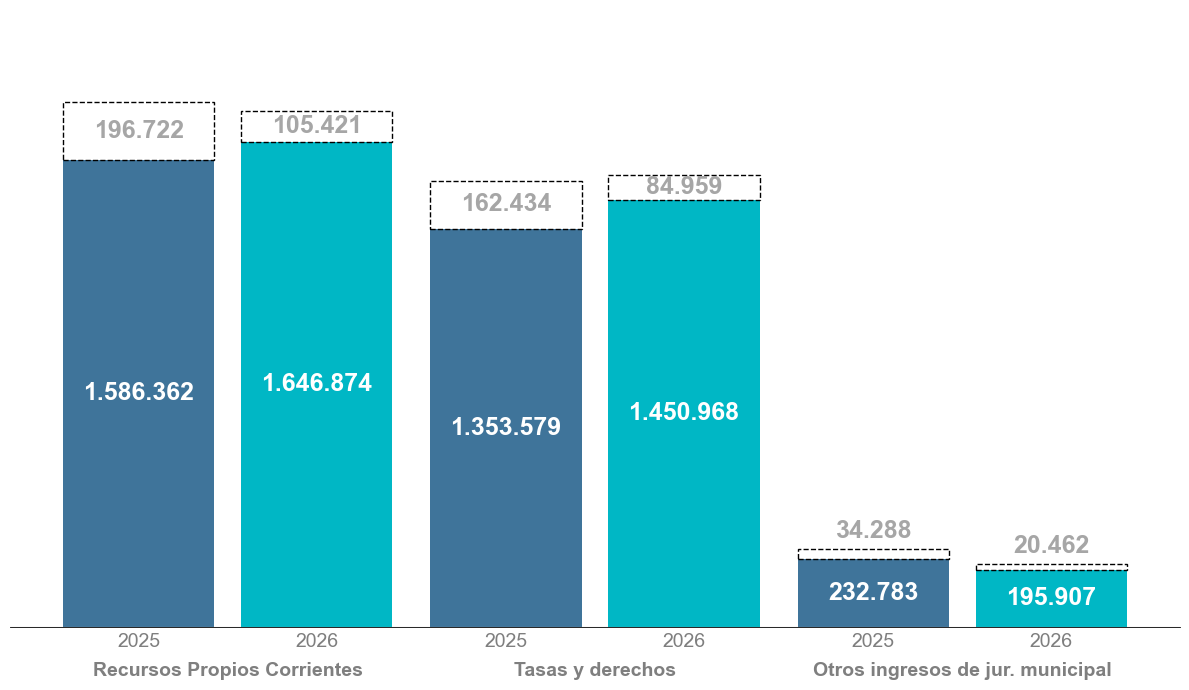

In [ ]:
# -------------------------------
# DATOS
# -------------------------------

df_graf = pd.DataFrame({

    'Año anterior': [
        df_filtrado_rcp['Total_rcp_mun_disp_defl_acum'].iloc[-13],
        df_filtrado_tyd['Total_tyd_mun_disp_defl_acum'].iloc[-13],
        df_filtrado_otros['Total_otros_mun_disp_defl_acum'].iloc[-13]
    ],

    'Último mes': [
        df_filtrado_rcp['Total_rcp_mun_disp_defl_acum'].iloc[-1],
        df_filtrado_tyd['Total_tyd_mun_disp_defl_acum'].iloc[-1],
        df_filtrado_otros['Total_otros_mun_disp_defl_acum'].iloc[-1]
    ],

    # Parte restante para borde punteado
    'Restante anterior': [
        df_filtrado_rcp['rcp_restante_defl_acum'].iloc[-13],
        df_filtrado_tyd['tyd_restante_defl_acum'].iloc[-13],
        df_filtrado_otros['otros_restante_defl_acum'].iloc[-13]
    ],

    'Restante último': [
        df_filtrado_rcp['rcp_restante_defl_acum'].iloc[-1],
        df_filtrado_tyd['tyd_restante_defl_acum'].iloc[-1],
        df_filtrado_otros['otros_restante_defl_acum'].iloc[-1]
    ]

},

index=[
    'Recursos Propios Corrientes',
    'Tasas y derechos',
    'Otros ingresos de jur. municipal'
])

# -------------------------------
# CONFIGURACIÓN
# -------------------------------

espacio = 0.85

x = np.arange(len(df_graf)) * espacio

ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# -------------------------------
# BARRAS PRINCIPALES
# -------------------------------

barras_anterior = ax.bar(
    x - ancho/1.7,
    df_graf['Año anterior'],
    width=ancho,
    color='#3F749A',
    zorder=2
)

barras_ultimo = ax.bar(
    x + ancho/1.7,
    df_graf['Último mes'],
    width=ancho,
    color='#00B7C5',
    zorder=2
)

# -------------------------------
# CAPAS PUNTEADAS ARRIBA
# -------------------------------

borde_anterior = ax.bar(
    x - ancho/1.7,
    df_graf['Restante anterior'],
    width=ancho,
    bottom=df_graf['Año anterior'],
    color='none',
    edgecolor='black',
    linewidth=1,
    linestyle='--',
    zorder=3
)

borde_ultimo = ax.bar(
    x + ancho/1.7,
    df_graf['Restante último'],
    width=ancho,
    bottom=df_graf['Último mes'],
    color='none',
    edgecolor='black',
    linewidth=1,
    linestyle='--',
    zorder=3
)

# -------------------------------
# FORMATO EJE Y
# -------------------------------

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f'{int(x):,}'.replace(',', '.')
    )
)

# Más aire arriba
ymin, ymax = ax.get_ylim()

ax.set_ylim(
    ymin,
    ymax * 1.12
)

# -------------------------------
# ETIQUETAS DENTRO DE LAS BARRAS
# -------------------------------

for barras in [barras_anterior, barras_ultimo]:

    for b in barras:

        height = b.get_height()

        ax.text(
            b.get_x() + b.get_width()/2,
            height * 0.5,
            f'{height/1_000_000:,.0f}'.replace(',', '.'),
            ha='center',
            va='center',
            fontsize=18,
            color='white',
            fontweight='bold',
            fontname='Arial'
        )

# -------------------------------
# ETIQUETAS DEL BORDE DENTRO DE LAS BARRAS
# -------------------------------

for barras_base, barras_borde in zip(
    [barras_anterior, barras_ultimo],
    [borde_anterior, borde_ultimo]
):

    for base, borde in zip(barras_base, barras_borde):

        valor = borde.get_height()

        texto = (
            f'{valor/1_000_000:,.0f}'
            .replace(',', '.')
        )

        # -------------------------------
        # POSICIÓN DEL TEXTO
        # -------------------------------

        # Si el valor es chico -> arriba
        if valor < 50_000_000_000:

            y_text = (
                base.get_height() +
                valor +
                ymax * 0.01
            )

            va_text = 'bottom'

        # Si no -> dentro del área punteada
        else:

            y_text = (
                base.get_height() +
                valor / 2
            )

            va_text = 'center'

        # -------------------------------
        # TEXTO
        # -------------------------------

        ax.text(
            base.get_x() + base.get_width()/2,
            y_text,
            texto,

            ha='center',
            va=va_text,

            linespacing=1.5,

            fontsize=18,
            color='#A6A6A6',
            fontweight='bold',
            fontname='Arial'
        )
# -------------------------------
# EJE X
# -------------------------------

ax.set_xticks(x)

ax.tick_params(
    axis='x',
    length=0,
    pad=25
)

ax.set_xticklabels(
    df_graf.index,
    fontname='Arial',
    fontsize=14,
    color='#7F7F7F',
    fontweight = 'bold'
)

# -------------------------------
# AÑOS DEBAJO DE CADA BARRA
# -------------------------------

anio_anterior = df_filtrado_rcp.index[-13].year
anio_actual = df_filtrado_rcp.index[-1].year

for i in range(len(x)):

    # Año anterior
    ax.text(
        x[i] - ancho/1.7,
        -ymax * 0.01,
        str(anio_anterior),
        ha='center',
        va='top',
        fontsize=14,
        color='#7F7F7F',
        fontname='Arial'
    )

    # Último mes
    ax.text(
        x[i] + ancho/1.7,
        -ymax * 0.01,
        str(anio_actual),
        ha='center',
        va='top',
        fontsize=14,
        color='#7F7F7F',
        fontname='Arial'
    )

ax.tick_params(axis='x', length=0)

# -------------------------------
# ESTÉTICA
# -------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(axis='y', length=0)

for label in ax.get_yticklabels():

    label.set_fontname('Arial')
    label.set_fontsize(14)
    label.set_color('#7F7F7F')

# Ocultar eje Y
ax.set_yticklabels([])

# Línea base
ax.axhline(
    0,
    color='#B0B0B0',
    linewidth=0.8
)

# -------------------------------
# EXPORTACIÓN
# -------------------------------

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '3. Barras apiladas Acum_rcp_tyd_otros.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras horizontales con eje centrado Acumulado YoY:
* Recursos Propios
* Tasas y derechos
* Otros

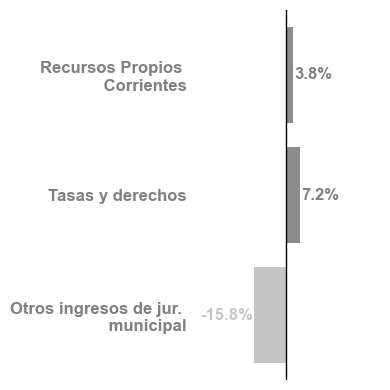

In [ ]:
df_graf_yoy = pd.DataFrame({

    'Año anterior': [

        df_filtrado_otros['Total_otros_mun_disp_defl_acum'].iloc[-13],
        df_filtrado_tyd['Total_tyd_mun_disp_defl_acum'].iloc[-13],

        df_filtrado_rcp['Total_rcp_mun_disp_defl_acum'].iloc[-13]

    ],

    'Último mes': [

        df_filtrado_otros['Total_otros_mun_disp_defl_acum'].iloc[-1],
        df_filtrado_tyd['Total_tyd_mun_disp_defl_acum'].iloc[-1],

        df_filtrado_rcp['Total_rcp_mun_disp_defl_acum'].iloc[-1]

    ]
})

categorias = ['Otros ingresos de jur. \n municipal','Tasas y derechos','Recursos Propios \n Corrientes']

variacion = (
    (
        df_graf_yoy['Último mes'] /
        df_graf_yoy['Año anterior']
    ) - 1
) * 100

variacion = variacion.values

# Crear figura
fig, ax = plt.subplots(figsize=(4, 4))

# Crear colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# Posiciones en eje Y
y = range(len(categorias))

# Barras
ax.barh(
    y,
    variacion,
    color=colores
)

# Línea vertical en cero
ax.axvline(0, color='black', linewidth=1)

# hacer barras más cortas
max_val = max(abs(variacion))
ax.set_xlim(-max_val*3, max_val*3)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.set_yticklabels(categorias, fontname="Arial", fontsize=12, color="#7F7F7F", fontweight='bold')

ax.tick_params(axis='y', length=0)

# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):

    if v > 0:
        color = "#7F7F7F"
    else:
        color = "#C5C5C5"

    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )
# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '4. Barras horizontales YoY_rcp_tyd_otros.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

## Transferencias PBA a municipios

#### Gráfico de barras apiladas
* Coparticipación Bruta
* Resto de transferencias

In [ ]:
#fiscal_fondos.columns = fiscal_fondos.columns.str.strip()
#pd.set_option('display.float_format', '{:.2f}'.format)
#fiscal_fondos.tail(14)

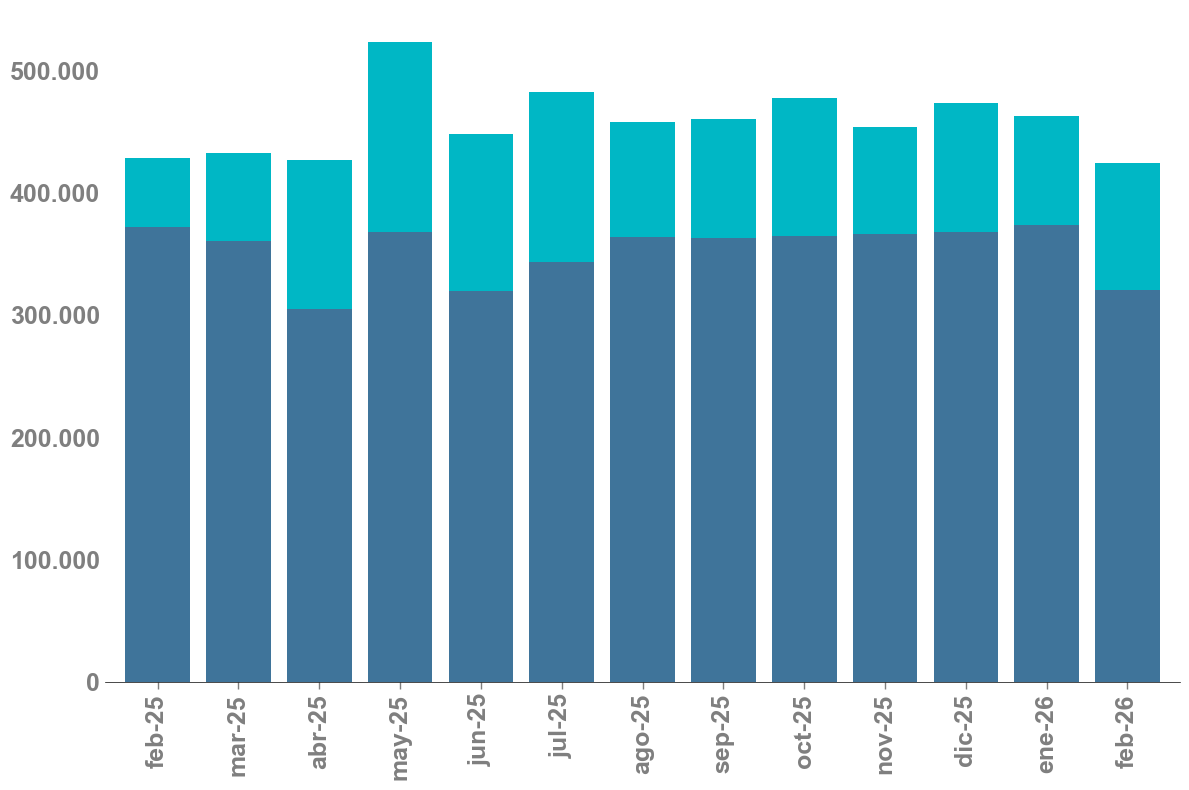

In [ ]:
# -------------------------------
# PREPARACIÓN DE DATOS
# -------------------------------

df_filtrado_fondos = fiscal_fondos.loc[:fecha_corte].copy()

# Últimos 13 meses
ultimo_13_meses = df_filtrado_fondos.tail(13)

# Variables del gráfico
df_grafico = ultimo_13_meses[
    ['coparticipacion_bruta_defl', 'resto_transferencias_defl']
].copy()

# Asegurar datetime
df_grafico.index = pd.to_datetime(df_grafico.index)

# -------------------------------
# FECHAS EN ESPAÑOL
# -------------------------------

meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_grafico.index
]

# Resetear índice para evitar problemas con PeriodIndex
df_grafico = df_grafico.reset_index(drop=True)

# -------------------------------
# CREAR FIGURA
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

# -------------------------------
# BARRAS APILADAS
# -------------------------------

df_grafico.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#3F749A', '#00B7C5'],
    width=0.8
)

# -------------------------------
# EJE X
# -------------------------------

positions = np.arange(len(fechas_esp))

ax.set_xticks(positions)
ax.set_xticklabels(fechas_esp, rotation=90)

ax.set_xlabel('')

# -------------------------------
# EJE Y
# -------------------------------

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f'{x / 1e6:,.0f}'.replace(',', '.')
    )
)

ax.set_ylabel('')

# -------------------------------
# ESTÉTICA
# -------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

ax.tick_params(
    axis='x',
    which='major',
    length=5,
    width=1,
    color='#7F7F7F'
)

ax.tick_params(
    axis='y',
    length=0
)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):

    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(18)
    label.set_color('#7F7F7F')

# -------------------------------
# FINAL
# -------------------------------

plt.legend().remove()

plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(
    os.path.join(ruta_completa, '5. Barras apiladas CB_Resto.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Gráfico de líneas YoY
* Total
* Coparticipación Bruta
* Resto de transferencias

C:\Users\janis\AppData\Local\Temp\ipykernel_24564\660698703.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(


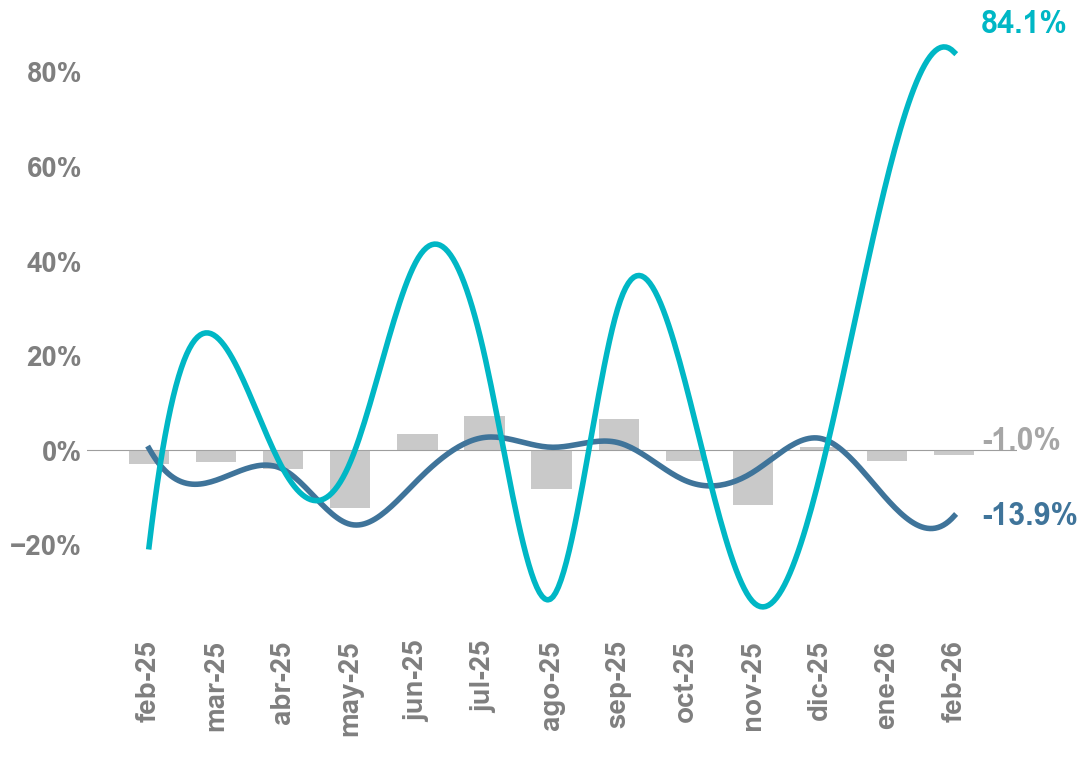

In [ ]:
# -------------------------------
# DATOS
# -------------------------------

variables = ['total_defl', 'coparticipacion_bruta_defl', 'resto_transferencias_defl']

df_vi = df_filtrado_fondos[variables].pct_change(12) * 100
df_vi = df_vi.dropna().tail(13)

x = np.arange(len(df_vi))

colors = {
    'total_defl': '#A6A6A6',
    'coparticipacion_bruta_defl': '#3F749A',
    'resto_transferencias_defl': '#00B7C5'
}

# -------------------------------
# FIGURA
# -------------------------------

fig, ax = plt.subplots(figsize=(12, 8))


# Ranking para etiquetas
last_vals = [(col, df_vi[col].values[-1]) for col in variables]
last_vals_sorted = sorted(last_vals, key=lambda x: x[1])
rank_dict = {col: rank for rank, (col, _) in enumerate(last_vals_sorted)}

# -------------------------------
# PLOTEO
# -------------------------------

for col in variables:

    y = df_vi[col].values

    # Barras
    if col == 'total_defl':

        ax.bar(
            x,
            y,
            color=colors[col],
            width=0.6,
            alpha=0.6,
            zorder=1
        )

    # Líneas suavizadas
    else:
        x_new = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        y_smooth = spline(x_new)

        ax.plot(
            x_new,
            y_smooth,
            color=colors[col],
            linewidth=4,
            zorder=3
        )

    # Etiqueta último valor
    last_x = x[-1]
    last_y = y[-1]
    offset = rank_dict[col] * 3

    ax.text(
        last_x + 0.4,
        last_y + offset,
        f"{last_y:.1f}%",
        color=colors[col],
        fontsize=22,
        fontweight='bold',
        fontname='Arial',
        va='center'
    )

# -------------------------------
# EJE X
# -------------------------------

meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"{meses_esp[d.month - 1]}-{str(d.year)[-2:]}"
    for d in df_vi.index
]

ax.set_xticks(x)
ax.set_xticklabels(fechas_esp, rotation=90)
ax.tick_params(axis='x', length=0)

# -------------------------------
# EJE Y
# -------------------------------

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='y', length=0)

# -------------------------------
# ESTÉTICA
# -------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(20)
    label.set_color('#7F7F7F')

ax.axhline(0, color='#9E9E9E', linewidth=0.8, zorder=0)

ax.set_xlabel('')

# -------------------------------
# FINAL
# -------------------------------
#plt.tight_layout()
#fig.subplots_adjust(bottom=0.2)

legend = ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    frameon=False,
    fontsize=16
)


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '6. Líneas YoY - CB_Resto_Total.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras comparativo Acumulado último mes y año anterior
* Total
* Coparticipación Bruta
* Resto de transferencias

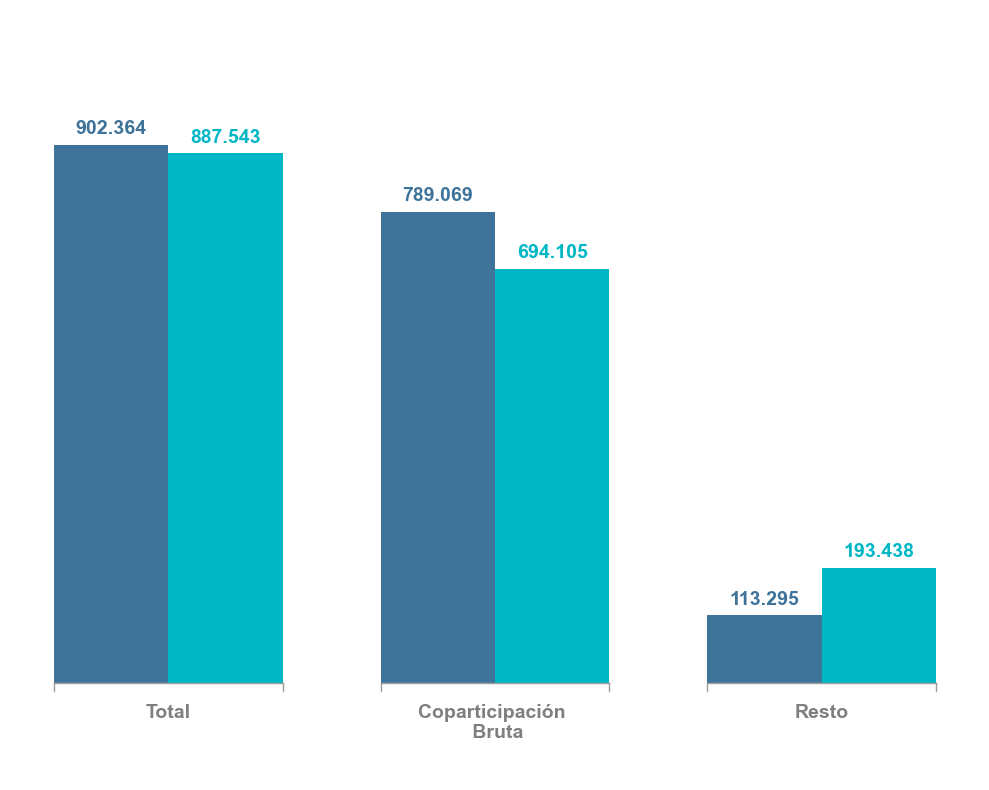

In [ ]:
# -----------------------------
# Seleccionar último mes y año anterior
# -----------------------------
ultimo_mes = df_filtrado_fondos.iloc[-1]
año_anterior = df_filtrado_fondos.iloc[-13]

variables_acum = [
    'total_defl_acum',
    'coparticipacion_bruta_defl_acum',
    'resto_transferencias_defl_acum'

]

val_ultimo = ultimo_mes[variables_acum].values
val_anterior = año_anterior[variables_acum].values

x = np.arange(len(variables_acum))
ancho = 0.35

# -----------------------------
# Figura
# -----------------------------
fig, ax = plt.subplots(figsize=(10,8))

barras1 = ax.bar(
    x - ancho/2,
    val_anterior,
    width=ancho,
    color='#3F749A'
)

barras2 = ax.bar(
    x + ancho/2,
    val_ultimo,
    width=ancho,
    color='#00B7C5'
)

# -----------------------------
# Límites del gráfico
# -----------------------------
ymax = max(val_ultimo.max(), val_anterior.max())
ax.set_ylim(-ymax*0.18, ymax*1.25)

# -----------------------------
# Quitar ejes
# -----------------------------
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', length=0)

# -----------------------------
# Etiquetas eje X
# -----------------------------

ax.set_xticks(x)

ax.set_xticklabels(
[
    'Total',
    'Coparticipación \n Bruta',
    'Resto',
],
fontname='Arial',
fontweight='bold',
fontsize=14,
color='#7F7F7F'
)

# subir etiquetas
ax.xaxis.set_tick_params(pad=-55)

# -----------------------------
# Línea inferior con brackets
# -----------------------------
y_base = 0
tick_height = ymax * 0.015

for i in range(len(x)):

    left = x[i] - ancho
    right = x[i] + ancho

    # línea horizontal
    ax.plot(
        [left, right],
        [y_base, y_base],
        color='#9E9E9E',
        linewidth=1
    )

    # tick izquierdo
    ax.plot(
        [left, left],
        [y_base, y_base - tick_height],
        color='#9E9E9E',
        linewidth=1
    )

    # tick derecho
    ax.plot(
        [right, right],
        [y_base, y_base - tick_height],
        color='#9E9E9E',
        linewidth=1
    )

# -----------------------------
# Etiquetas sobre barras
# -----------------------------
offset_pixels_barra1 = 5
offset_pixels_barra2 = 5

for b in barras1:

    height = b.get_height()

    trans = transforms.ScaledTranslation(
        0,
        offset_pixels_barra1/72,
        fig.dpi_scale_trans
    )

    ax.text(
        b.get_x() + b.get_width()/2,
        height,
        f'{height / 1e6:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#3F749A',
        fontweight='bold'
    )

for b in barras2:

    height = b.get_height()

    trans = transforms.ScaledTranslation(
        0,
        offset_pixels_barra2/72,
        fig.dpi_scale_trans
    )

    ax.text(
        b.get_x() + b.get_width()/2,
        height,
        f'{height / 1e6:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#00B7C5',
        fontweight='bold'
    )


plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '7. Barras comparativas - CB_Resto_Total.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras horizontales con eje centrado Acumulado YoY:
* Total
* Coparticipación Bruta
* Resto de transferencias

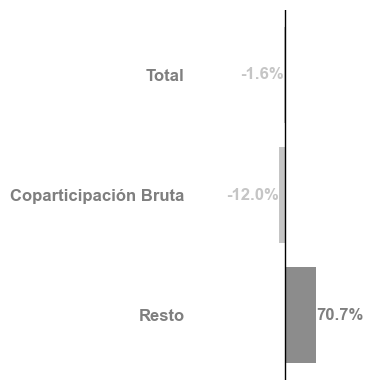

In [ ]:
variables_acum = variables_acum[::-1]

categorias = ['Resto', 'Coparticipación Bruta','Total']

df_vi = df_filtrado_fondos[variables_acum].pct_change(12) * 100

# Convertir variación en vector
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(4, 4))

# Crear colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# Posiciones en eje Y
y = range(len(categorias))

# Barras
ax.barh(
    y,
    variacion,
    color=colores
)

# Línea vertical en cero
ax.axvline(0, color='black', linewidth=1)

# hacer barras más cortas
max_val = max(abs(variacion))
ax.set_xlim(-max_val*3, max_val*3)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.set_yticklabels(categorias, fontname="Arial", fontsize=12, color="#7F7F7F", fontweight='bold')

ax.tick_params(axis='y', length=0)

# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):

    if v > 0:
        color = "#7F7F7F"
    else:
        color = "#C5C5C5"

    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )
# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '8. Barras horizontales YoY - CB_Resto_Total.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras apiladas Acumulado último año y año anterior
* Descentralización
* Juegos de Azar
* F.F.P.S. (Planes Sociales)
* Fortalecimiento Recaudación Municipal
* Fondo Inc Social
* Fondo de Financiamiento Educativo
* Resto Fondos Especiales

In [ ]:
fiscal_fondos.index = pd.to_datetime(fiscal_fondos.index)


especiales = ['descentralizacion_defl_acum', 'juegos_azar_defl_acum','ffps_defl_acum','fort_rec_muni_defl_acum','fond_inc_social_defl_acum','fond_fin_educ_defl_acum']

fiscal_fondos['resto_especiales_defl_acum'] = (
    fiscal_fondos['total_defl_acum']
    - fiscal_fondos['coparticipacion_bruta_defl_acum']
    - fiscal_fondos[especiales].sum(axis=1))


ultimo_mes_fecha = df_filtrado_fondos.index.max()
fecha_año_anterior = ultimo_mes_fecha - pd.DateOffset(years=1)

df_grafico = fiscal_fondos.loc[
    [fecha_año_anterior, ultimo_mes_fecha],
    [
        'descentralizacion_defl_acum',
        'juegos_azar_defl_acum',
        'ffps_defl_acum',
        'fort_rec_muni_defl_acum',
        'fond_inc_social_defl_acum',
        'fond_fin_educ_defl_acum',
        'resto_especiales_defl_acum'
    ]
]

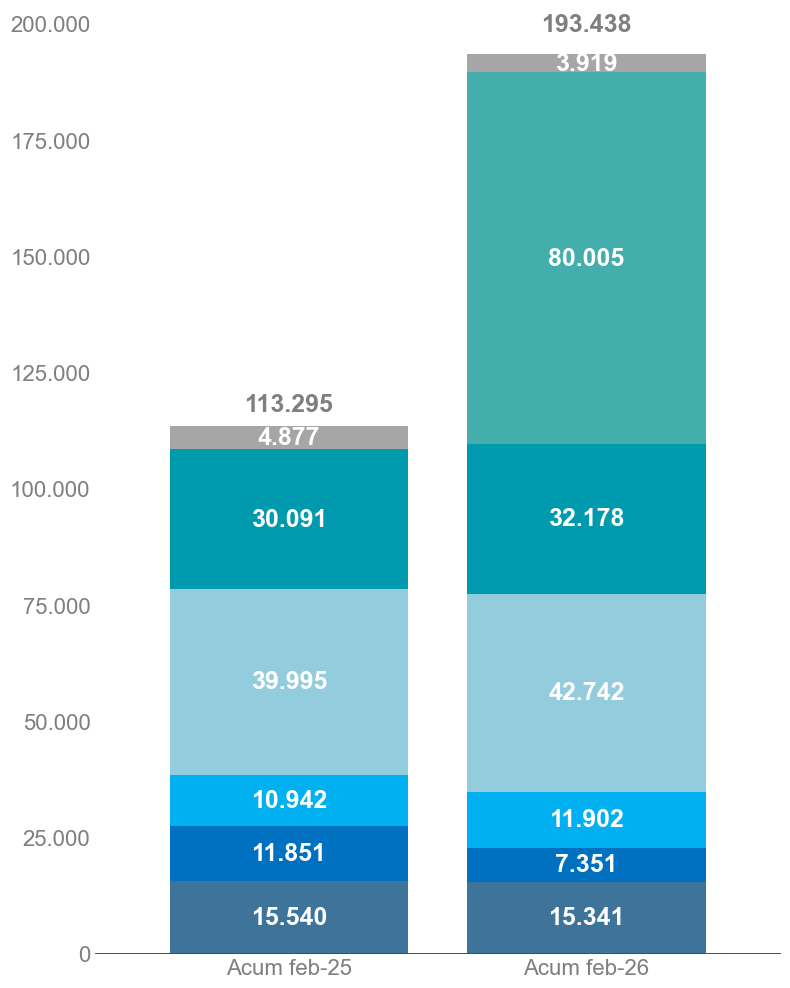

In [ ]:
# -------------------------------
# PREPARACIÓN DE DATOS
# -------------------------------

# Asegurar índice datetime
df_grafico.index = pd.to_datetime(df_grafico.index)

# Ordenar por fecha
df_grafico = df_grafico.sort_index()

# Eliminar filas completamente vacías (evita barras sin datos)
df_grafico = df_grafico.dropna(how='all')

# -------------------------------
# CREAR FIGURA
# -------------------------------

fig, ax = plt.subplots(figsize=(8, 10))

colores_acum = ['#3F749A', '#0070C0','#00B0F0','#93CDDD','#009AAE','#44AEAC','#A6A6A6']

# Barras apiladas
df_grafico.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colores_acum,
    width=0.8
)

# -------------------------------
# ETIQUETAS DENTRO DE LAS BARRAS
# -------------------------------

for container in ax.containers:
    for bar in container:

        height = bar.get_height()

        # evitar etiquetas en valores muy chicos o cero
        if height <= 0:
            continue

        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_y() + height / 2

        ax.text(
            x,
            y,
            f'{height/1e6:,.0f}'.replace(',', '.'),
            ha='center',
            va='center',
            color='white',
            fontsize=18,
            fontweight='bold',
            fontname='Arial'
        )


# -------------------------------
# ETIQUETA TOTAL ARRIBA DE CADA BARRA
# -------------------------------

# suma total por barra (columna)
totales = df_grafico.sum(axis=1).values

for i, total in enumerate(totales):

    ax.text(
        i,
        total + total * 0.02,  # pequeño offset vertical
        f'{total/1e6:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=18,
        fontweight='bold',
        fontname='Arial',
        color='#7F7F7F'
    )
# -------------------------------
# EJE X (fechas en español)
# -------------------------------

meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"{meses_esp[d.month - 1]}-{str(d.year)[-2:]}"
    for d in df_grafico.index
]

labels_acum = [f'Acum {f}' for f in fechas_esp]

ax.set_xticks(range(len(df_grafico)))
ax.set_xticklabels(labels_acum, rotation=0)

ax.set_xlabel('')

# -------------------------------
# EJE Y (en millones)
# -------------------------------

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'{x / 1e6:,.0f}'.replace(',','.'))
)

# -------------------------------
# ESTÉTICA
# -------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

#ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

ax.tick_params(axis='x', length=0)

ax.tick_params(axis='y', length=0)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontsize(16)
    label.set_color('#7F7F7F')

#ax.set_ylabel('Millones de $',
#              fontname='Arial',
#              fontsize=18,
#              color='#7F7F7F')

# -------------------------------
# FINAL
# -------------------------------

plt.legend().remove()
plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '9. Barras apiladas - Especiales.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico barras horizontales con eje centrado Acumulado YoY:
* Descentralización
* Juegos de Azar
* F.F.P.S. (Planes Sociales)
* Fortalecimiento Recaudación Municipal
* Fondo Inc Social
* Fondo de Financiamiento Educativo
* Resto Fondos Especiales


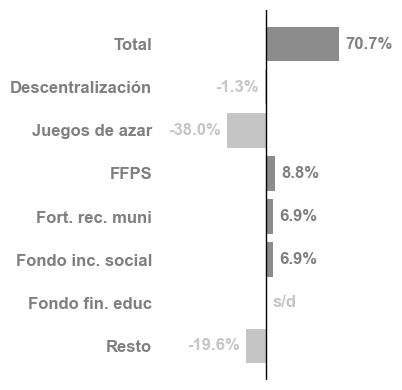

In [ ]:
# -------------------------------
# VARIABLES (especiales + resto)
# -------------------------------

especiales = [
    'resto_transferencias_defl_acum',
    'descentralizacion_defl_acum',
    'juegos_azar_defl_acum',
    'ffps_defl_acum',
    'fort_rec_muni_defl_acum',
    'fond_inc_social_defl_acum',
    'fond_fin_educ_defl_acum',
    'resto_especiales_defl_acum'
]

# etiquetas
categorias_esp = [
    'Total',
    'Descentralización',
    'Juegos de azar',
    'FFPS',
    'Fort. rec. muni',
    'Fondo inc. social',
    'Fondo fin. educ',
    'Resto'
]

# -------------------------------
# VARIACIÓN INTERANUAL
# -------------------------------

df_vi = fiscal_fondos[especiales].pct_change(12) * 100

# reemplazar inf por NaN
df_vi = df_vi.replace([np.inf, -np.inf], np.nan)

# quedarte con última fila válida
variacion = df_vi.iloc[-1].fillna(0).values

# -------------------------------
# FIGURA
# -------------------------------

fig, ax = plt.subplots(figsize=(4, 4))

# colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# posiciones eje Y
y = np.arange(len(categorias_esp))

# barras
ax.barh(
    y,
    variacion,
    color=colores
)

# línea en cero
ax.axvline(0, color='black', linewidth=1)

# límites eje X
max_val = np.max(np.abs(variacion))

ax.set_xlim(
    -max_val * 1.5,
     max_val * 1.5
)

# etiquetas eje Y
ax.set_yticks(y)
ax.set_yticklabels(
    categorias_esp,
    fontname="Arial",
    fontsize=12,
    color="#7F7F7F",
    fontweight='bold'
)

ax.tick_params(axis='y', length=0)

# opcional: invertir eje para estilo informe
ax.invert_yaxis()

# -------------------------------
# ESTÉTICA
# -------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.grid(False)
ax.get_xaxis().set_visible(False)

# -------------------------------
# ETIQUETAS DE VALOR
# -------------------------------

for i, v in enumerate(variacion):

    color = "#7F7F7F" if v > 0 else "#C5C5C5"

    # Texto a mostrar
    texto = 's/d' if v == 0 else f"{v:.1f}%"

    offset = 6

    ax.text(
        v + (offset if v >= 0 else -offset),
        i,
        texto,
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )



# -------------------------------
# FINAL
# -------------------------------

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

plt.savefig(os.path.join(ruta_completa, '10. Barras horizontales YoY - Especiales.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

### Gráfico de barras
* Total transferencias de Nación a Municipios

In [ ]:
fiscal_municipios['Total_transf_muni'] = fiscal_municipios.select_dtypes(include='number').iloc[:, 2:].sum(axis=1)

fiscal_municipios['Total_transf_muni_defl'] = (
    fiscal_municipios['Total_transf_muni'] * ipc_base / fiscal_municipios['IPC Dic16=100'])

df_filtrado_municipios = fiscal_municipios.loc[:fecha_corte].copy()


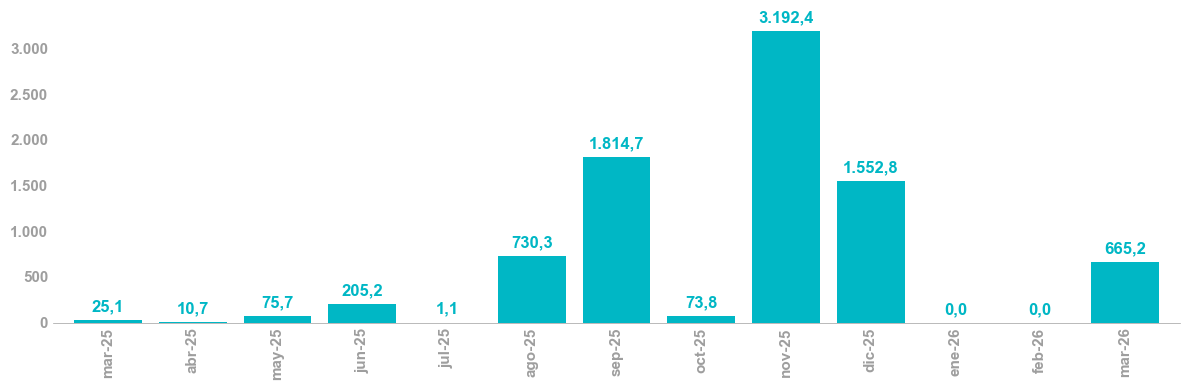

In [ ]:
# ---------------------------
# Preparación de datos
# ---------------------------

# Tomar últimos 13 meses
df_grafico = df_filtrado_municipios['Total_transf_muni_defl'].tail(13).copy()

# Formato fechas en español directamente en el índice
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

df_grafico.index = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_grafico.index
]

# ---------------------------
# Gráfico
# ---------------------------

fig, ax = plt.subplots(figsize=(12, 4))

df_grafico.plot(
    kind='bar',
    ax=ax,
    color=["#00B7C5"],
    width=0.8
)

offset = df_grafico.max() * 0.02

for i, v in enumerate(df_grafico):
    valor = f"{v:,.1f}".replace(",", "X").replace(".", ",").replace("X", ".")

    ax.text(
        i,
        v + offset,
        valor,
        ha='center',
        va='bottom',
        fontsize=12,
        fontname='Arial',
        fontweight='bold',
        color='#00B7C5'
    )
ax.set_xlabel('')

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['bottom'].set_color('#9E9E9E')

# Ticks
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

# Fuente
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_color("#9E9E9E")

# Eje Y
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f'{x:,.0f}'.replace(',', '.')
    )
)

for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Arial')
    tick.label1.set_fontsize(11)
    tick.label1.set_color("#9E9E9E")

# Quitar leyenda
ax.legend().remove()

# Grid
#ax.yaxis.grid(True, linestyle='-', linewidth=0.9, alpha=0.3)

# ---------------------------
# Export / render
# ---------------------------

plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '11. Barras Total Transf. Nación a Municipos.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()